In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
m = 0.1
M = 1.1
l = 0.5
g = 9.81
k = 1 / 3
T = 0.02

Reward function parameters (used the first proposal from the pdf for the reward function)

In [29]:
THETA_TH = np.deg2rad(12)
ALPHA    = 2

Nonlinear equations used to model the inverted pendulum

In [30]:
def f_theta(z, F):
    _, _, th, th_dot = z
    num = M * g * np.sin(th) - np.cos(th) * (F + m * l * th_dot**2 * np.sin(th))
    den = (1 + k) * M * l - m * l * np.cos(th)**2
    return num / den

In [31]:
def f_x(z, F):
    _, _, th, th_dot = z
    num = m * g * np.sin(th) * np.cos(th) - (1 + k) * (F + m * l * th_dot**2 * np.sin(th))
    den = m * np.cos(th)**2 - (1 + k) * M
    return num / den

Discretization (Euler 1)

In [32]:
def step_env(z, F):
    z1, z2, z3, z4 = z
    return np.array([
        z1 + T * z2,
        z2 + T * f_x(z, F),
        z3 + T * z4,
        z4 + T * f_theta(z, F),
    ])

def reward(theta):
    if abs(theta) < THETA_TH:
        return -abs(theta) ** ALPHA
    return -1000.0

def is_done(z):
    x, _, theta, _ = z
    return abs(theta) >= THETA_TH or abs(x) > 2.4


Observation Space






N_BINS = [10, 10, 20, 20]:
- cart position x is divided into 10 equal parts
- cart velocity x_dot is divided into 10 equal parts
- the pole (pendulum) angle relative to the vertical axis, theta, is divided into 20 equal parts
- angular velocity theta_dot is divided into 20 equal parts

The angle and its velocity are more important for the stability of this system. A small change in angle affects whether the pole will fall or remain in a balanced position. Because of this we need greater precision, hence 20 equal parts. Unlike the cart position and velocity, for which we have 10. Whether the cart is at position x = 0.1m or x = 0.2m does not make that much of a difference to the system's behavior, which is why 10 larger parts are sufficient


- cart position x in the range (-2.4, 2.4) meters: The cart is assumed to be on a track that is 4.8 meters long in total (2.4 to the left and 2.4 to the right of the center). If the cart moves further than 2.4 meters, it has fallen off the track and the simulation ends

* source for the value: https://gymnasium.farama.org/environments/classic_control/cart_pole/

- the pole angle relative to the vertical axis (theta) in the range (-THETA_TH, THETA_TH) follows from the definition of the reward function I chose (the first proposal from the pdf)

- the bounds for velocity and angular velocity are used so that the np.clip function places any values of these features that fall outside these ranges at the edge of the Q-Learning table. I.e. any value below the lower bound is treated by the agent the same as the minimum, and above the upper bound the same as the maximum in the Q-table




In [33]:
FORCES    = np.array([-10.0, -5.0, 0.0, 5.0, 10.0])   # F in [-10, 10] N
N_ACTIONS = len(FORCES)

N_BINS = [10, 10, 20, 20]
STATE_BOUNDS = [
    (-2.4,      2.4),         # x  [m]
    (-3.0,      3.0),         # x_dot  [m/s]
    (-THETA_TH, THETA_TH),    # theta  [rad]
    (-4.0,      4.0),         # theta_dot  [rad/s]
]

In [34]:
def discretize(z):
    indices = []
    for val, (lo, hi), n in zip(z, STATE_BOUNDS, N_BINS):
        idx = int(np.clip((val - lo) / (hi - lo) * n, 0, n - 1))
        indices.append(idx)
    return tuple(indices)

##Q-Learning algorithm

Q-Learning table and hyperparameters

- Note on eps = 1.0

  I used a decaying epsilon, with maximum exploration at the start when the agent has no knowledge of the environment, and then multiplied it by 0.995 each episode until it reached a value of 0.01 -> minimal exploration, and maximum exploitation at the end


In [35]:
np.random.seed(42)
Q = np.zeros(N_BINS + [N_ACTIONS])

LR         = 0.1
GAMMA      = 0.99
eps        = 1.0
EPS_MIN    = 0.01
EPS_DECAY  = 0.995
N_EPISODES = 5000
MAX_STEPS  = 500

In [36]:
ep_rewards = []
ep_lengths = []

for ep in range(N_EPISODES):
    z = np.random.uniform(-0.05, 0.05, size=4)
    total_r = 0.0

    for t in range(MAX_STEPS):
        s = discretize(z)

        if np.random.random() < eps:
            a_idx = np.random.randint(N_ACTIONS)
        else:
            a_idx = int(np.argmax(Q[s]))

        z_next = step_env(z, FORCES[a_idx])
        r      = reward(z_next[2])
        done   = is_done(z_next)
        total_r += r

        s_next = discretize(z_next)
        target = r if done else r + GAMMA * np.max(Q[s_next])
        Q[s][a_idx] += LR * (target - Q[s][a_idx])

        z = z_next
        if done:
            break

    ep_rewards.append(total_r)
    ep_lengths.append(t + 1)
    eps = max(EPS_MIN, eps * EPS_DECAY)

    if (ep + 1) % 500 == 0:
        print(f"Ep {ep+1:5d} | "
              f"Avg reward: {np.mean(ep_rewards[-500:]):8.2f} | "
              f"Avg steps: {np.mean(ep_lengths[-500:]):6.1f} | "
              f"eps: {eps:.3f}")

Ep   500 | Avg reward: -1000.22 | Avg steps:   28.9 | eps: 0.082
Ep  1000 | Avg reward:  -904.27 | Avg steps:  120.1 | eps: 0.010
Ep  1500 | Avg reward:  -460.13 | Avg steps:  375.4 | eps: 0.010
Ep  2000 | Avg reward:  -674.17 | Avg steps:  355.6 | eps: 0.010
Ep  2500 | Avg reward:  -534.19 | Avg steps:  386.5 | eps: 0.010
Ep  3000 | Avg reward:  -214.08 | Avg steps:  460.9 | eps: 0.010
Ep  3500 | Avg reward:  -152.05 | Avg steps:  480.2 | eps: 0.010
Ep  4000 | Avg reward:  -184.05 | Avg steps:  477.2 | eps: 0.010
Ep  4500 | Avg reward:  -236.07 | Avg steps:  478.6 | eps: 0.010
Ep  5000 | Avg reward:  -202.06 | Avg steps:  483.5 | eps: 0.010


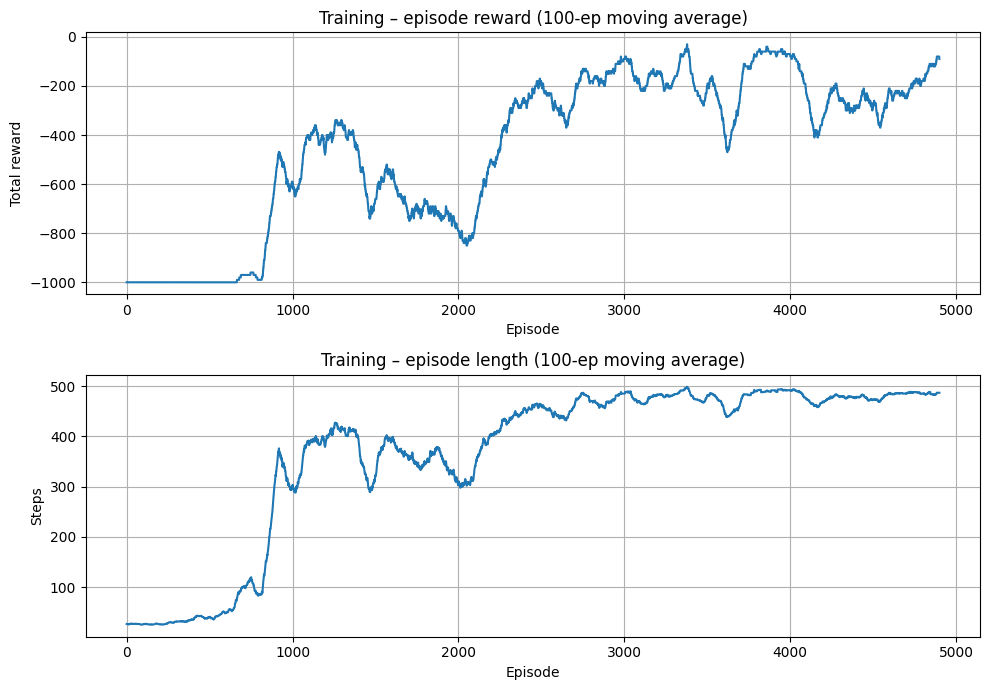

In [37]:
W = 100
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
ax1.plot(np.convolve(ep_rewards, np.ones(W) / W, 'valid'))
ax1.set(title='Training – episode reward (100-ep moving average)',
        xlabel='Episode', ylabel='Total reward')
ax1.grid(True)

ax2.plot(np.convolve(ep_lengths, np.ones(W) / W, 'valid'))
ax2.set(title='Training – episode length (100-ep moving average)',
        xlabel='Episode', ylabel='Steps')
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()


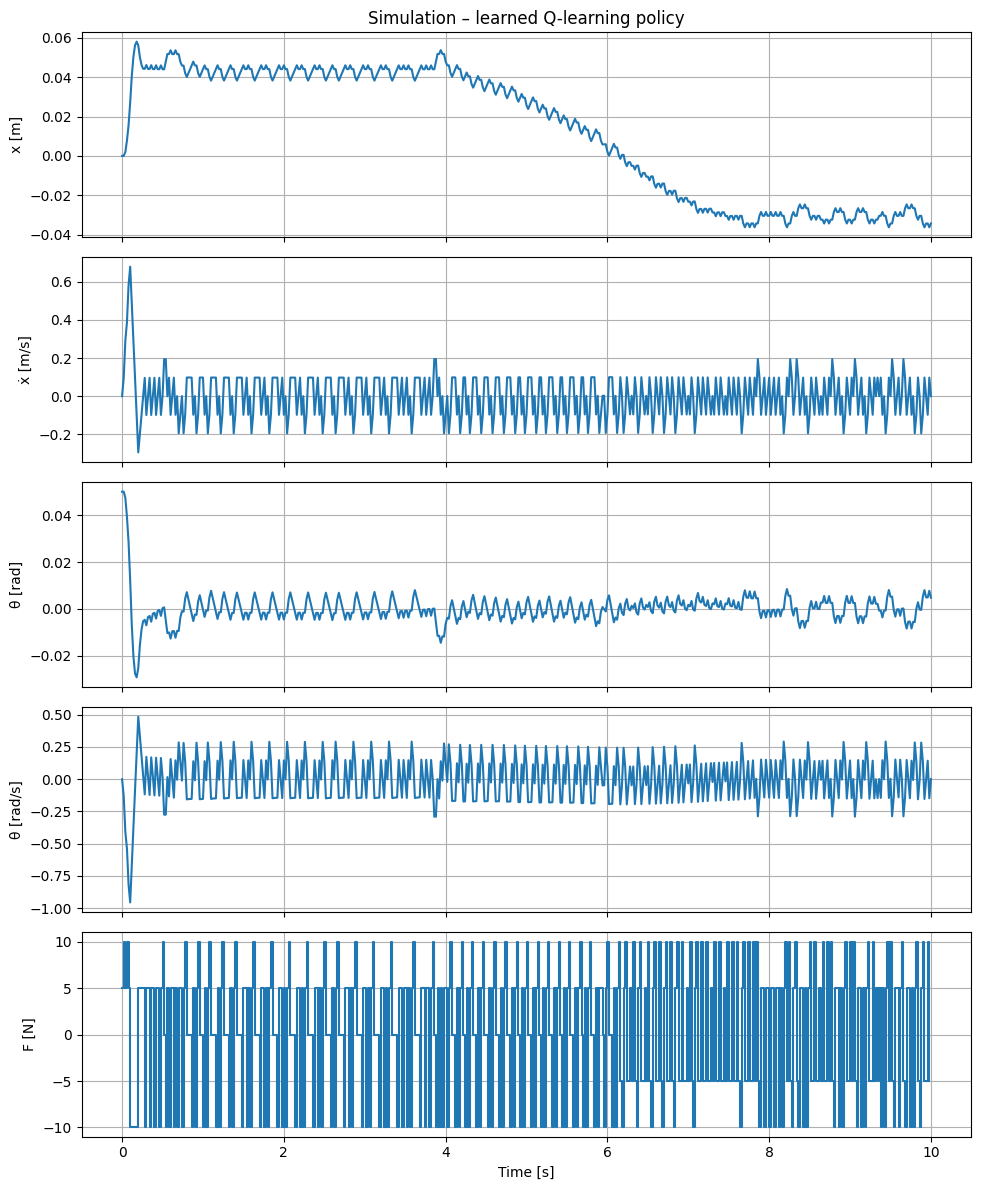


Pole balanced for 10.00 s  (500 steps)


In [38]:
z = np.array([0.0, 0.0, 0.05, 0.0])
history = [z.copy()]
applied_forces = []

for _ in range(MAX_STEPS):
    s     = discretize(z)
    a_idx = int(np.argmax(Q[s]))
    applied_forces.append(FORCES[a_idx])
    z = step_env(z, FORCES[a_idx])
    history.append(z.copy())
    if is_done(z):
        break

H      = np.array(history)
t_axis = np.arange(len(H)) * T

fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)
labels = ['x [m]', 'ẋ [m/s]', 'θ [rad]', 'θ̇ [rad/s]', 'F [N]']
for i, (ax, label) in enumerate(zip(axes, labels)):
    if i < 4:
        ax.plot(t_axis, H[:, i])
    else:
        ax.step(t_axis[:-1], applied_forces, where='post')
    ax.set_ylabel(label)
    ax.grid(True)

axes[-1].set_xlabel('Time [s]')
axes[0].set_title('Simulation – learned Q-learning policy')
plt.tight_layout()
plt.savefig('simulation_results.png', dpi=120)
plt.show()

print(f"\nPole balanced for {(len(H) - 1) * T:.2f} s  ({len(H) - 1} steps)")
